# Milestone 1
## Objective
The objective of this milestone is to:

1. Perform Exploratory Data Analysis (EDA)
2. Apply text preprocessing techniques
3. Generate TF-IDF representations
4. Compute cosine similarity scores
5. Establish a baseline retrieval system
6. Understand and evaluate performance using MAP@3

## Setup & Imports

In [3]:
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

plt.style.use('ggplot')
print("Setup complete")

Setup complete


## Data Loading

In [5]:
train_df = pd.read_csv('../data/train.csv')
test_df  = pd.read_csv('../data/test.csv')

# Ensure option columns are strings and NaNs are empty
for df in [train_df, test_df]:
    for col in ['A', 'B', 'C', 'D', 'E']:
        df[col] = df[col].fillna('').astype(str)

print(f"Train: {train_df.shape} | Test: {test_df.shape}")
print(f"Columns: {list(train_df.columns)}")
train_df.head(3)

Train: (2000, 8) | Test: (500, 7)
Columns: ['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer']


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C


---
## Q1: Answer Frequency Distribution
**Question:** Calculate the frequency distribution of the correct answer (A, B, C, D, E) in train.csv. What is the **sum of the occurrences of the most frequent and least frequent** option?

Answer Label Frequencies:
answer
A    369
B    490
C    459
D    358
E    324
Name: count, dtype: int64

Most Frequent : B (490)
Least Frequent: E (324)

Q1 Answer: 814


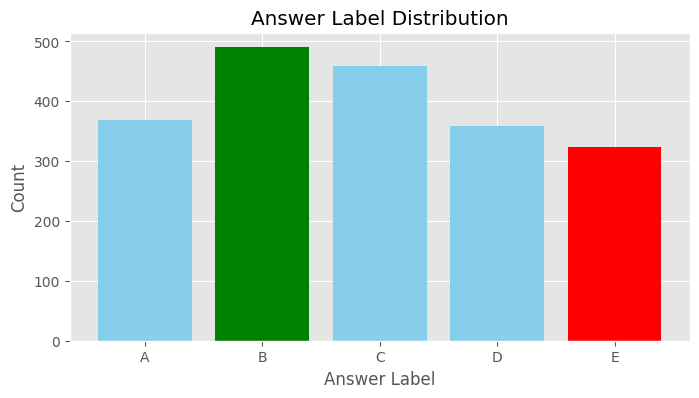

In [6]:
# Answer frequency distribution
ans_counts = train_df["answer"].value_counts().sort_index()

print("Answer Label Frequencies:")
print(ans_counts)

# Most and least frequent answers
most_label = ans_counts.idxmax()
least_label = ans_counts.idxmin()

q1_answer = ans_counts.max() + ans_counts.min()

print(f"\nMost Frequent : {most_label} ({ans_counts.max()})")
print(f"Least Frequent: {least_label} ({ans_counts.min()})")
print(f"\nQ1 Answer: {q1_answer}")

# Visualization
colors = [
    "green" if label == most_label
    else "red" if label == least_label
    else "skyblue"
    for label in ans_counts.index
]

plt.figure(figsize=(8, 4))
plt.bar(ans_counts.index, ans_counts.values, color=colors)
plt.title("Answer Label Distribution")
plt.xlabel("Answer Label")
plt.ylabel("Count")
plt.show()

---
## Q2: Vocabulary Size of Cleaned Prompt Column
**Question:** After converting the prompt column to **lowercase** and removing all standard punctuation (using `string.punctuation`), split by whitespace. What is the **total number of unique words** (vocabulary size) across the entire cleaned prompt column?

In [7]:
# Unique vocabulary size across cleaned prompts

def clean_q2(text):
    return str(text).lower().translate(
        str.maketrans('', '', string.punctuation)
    )

cleaned_prompts = train_df['prompt'].apply(clean_q2)

all_unique_words = set()
for prompt in cleaned_prompts:
    all_unique_words.update(prompt.split())

q2_answer = len(all_unique_words)

print("Original :", str(train_df['prompt'].iloc[0]))
print("Cleaned  :", cleaned_prompts.iloc[0])

print(f"\nQ2 Answer: {q2_answer}")

Original : Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.
Cleaned  : pick the best possible answer what is martin heideggers view on the relationship between time and human existence among the listed options

Q2 Answer: 859


---
## Q3: Stop Word Filtering on Row ID 1
**Question:** Using the cleaned prompt from **Row ID 1**, filter out standard English stop words using `sklearn.feature_extraction.text.ENGLISH_STOP_WORDS`. How many words are left after filtering?

In [8]:
# Stop-word filtering on Row ID 1

prompt = train_df.loc[train_df['id'] == 1, 'prompt'].iloc[0]

cleaned_prompt = clean_q2(prompt)

filtered_tokens = [
    word for word in cleaned_prompt.split()
    if word not in ENGLISH_STOP_WORDS
]

q3_answer = len(filtered_tokens)

print("Original :", str(prompt)[:250])
print("Cleaned  :", cleaned_prompt[:250])

print(f"\nRemaining Tokens: {filtered_tokens}")
print(f"\nQ3 Answer: {q3_answer}")

Original : Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.
Cleaned  : pick the best possible answer what is martin heideggers view on the relationship between time and human existence among the listed options

Remaining Tokens: ['pick', 'best', 'possible', 'answer', 'martin', 'heideggers', 'view', 'relationship', 'time', 'human', 'existence', 'listed', 'options']

Q3 Answer: 13


---
## Q4: TF-IDF Vocabulary Size
**Question:** Fit a **default `TfidfVectorizer(stop_words='english')`** on a list containing all the combined text of the prompts **and** options in train.csv. What is the **exact total number of feature columns** (vocabulary size) generated?

In [9]:
# Q4: TF-IDF vocabulary size on combined text (prompt + all 5 options per row)

def combine_row_text(row) -> str:
    """Concatenate prompt and all options into one string for a row."""
    parts = [str(row['prompt'])]
    for label in ['A', 'B', 'C', 'D', 'E']:
        parts.append(str(row[label]))
    return ' '.join(parts)

combined_texts = [combine_row_text(row) for _, row in train_df.iterrows()]

# Fit default TfidfVectorizer with stop_words='english'
vectorizer = TfidfVectorizer(stop_words='english')
vectorizer.fit(combined_texts)

q4_answer = len(vectorizer.vocabulary_)
print(f"Number of documents (rows) fitted: {len(combined_texts)}")
print(f"Q4 Answer: {q4_answer}")

Number of documents (rows) fitted: 2000
Q4 Answer: 2762


---
## Q5: Cosine Similarity
**Question:** Using the **TF-IDF vectorizer fitted in Q4**, calculate the cosine similarity between the **prompt** and **Option A** strictly for **Row ID 1**. Round to 4 decimal places.

In [10]:
# Cosine similarity: prompt vs Option A for Row ID 1

row1 = train_df[train_df['id'] == 1].iloc[0]

prompt_text = str(row1['prompt'])
option_a_text = str(row1['A'])

prompt_vec  = vectorizer.transform([prompt_text])
option_a_vec = vectorizer.transform([option_a_text])

sim_score = cosine_similarity(prompt_vec, option_a_vec)[0, 0]

print(f"Row ID 1 prompt: {prompt_text}")
print(f"Row ID 1 Option A: {option_a_text}")
print(f"\nQ5 Answer: {sim_score:.4f}")

Row ID 1 prompt: Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.
Row ID 1 Option A: Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a historical era, and the relationship to the future involves creating a world that will endure beyond one's own time.

Q5 Answer: 0.2720


---
## Q6: TF-IDF Cosine Accuracy Across All Rows
**Question:** For every row in train.csv, calculate the cosine similarity between the prompt and each of its 5 options. What is the **percentage of instances where the option with the highest cosine similarity matches the correct answer**?

In [11]:
# Batch cosine similarity: prompt vs each option, check accuracy

# Transform all prompts and all options at once
prompt_vecs = vectorizer.transform(train_df['prompt'].astype(str).tolist())

option_vecs = {}
for label in ['A', 'B', 'C', 'D', 'E']:
    option_vecs[label] = vectorizer.transform(train_df[label].astype(str).tolist())

# Normalise prompt vectors once
norm_prompts = normalize(prompt_vecs, norm='l2')

# Compute cosine similarity for each option
labels = ['A', 'B', 'C', 'D', 'E']
n = len(train_df)
sim_matrix = np.zeros((n, 5))

for i, label in enumerate(labels):
    norm_opt = normalize(option_vecs[label], norm='l2')

    sim_matrix[:, i] = np.array(norm_prompts.multiply(norm_opt).sum(axis=1)).flatten()

# Predicted labels
predicted_indices = np.argmax(sim_matrix, axis=1)
predicted_labels  = [labels[i] for i in predicted_indices]

# True labels
true_labels = train_df['answer'].astype(str).str.upper().tolist()

# Accuracy
correct = sum(p == t for p, t in zip(predicted_labels, true_labels))
accuracy_pct = correct / n * 100

print(f"Total rows evaluated: {n}")
print(f"Correct predictions: {correct}")
print(f"\nQ6 Answer: {accuracy_pct:.2f}%")

Total rows evaluated: 2000
Correct predictions: 271

Q6 Answer: 13.55%


---
## MAP@3 - Definition & Q7 / Q8

**MAP@3** (Mean Average Precision at 3) is defined as:

$$\text{AP@3} = \frac{1}{\text{rank of correct answer}}\quad \text{if correct answer is in top-3, else } 0$$

$$\text{MAP@3} = \frac{1}{N}\sum_{i=1}^{N} \text{AP@3}_i$$

**Q7:** Ground truth = **C**, prediction = **[C, A, B]**, C is rank 1, AP@3 = 1/1

**Q8:** Ground truth = **B**, prediction = **[D, B, E]**, B is rank 2, AP@3 = 1/2

In [12]:
# MAP@3 helper functions
def ap_at_3(predicted, actual, k=3):
    """AP@3 = 1/rank if actual is in top-k predictions, else 0."""
    if actual not in predicted[:k]:
        return 0.0
    return 1.0 / (predicted[:k].index(actual) + 1)

def map_at_3(predictions, actuals):
    """Mean AP@3 over all queries."""
    return float(np.mean([ap_at_3(p, a) for p, a in zip(predictions, actuals)]))


# Q7: ground truth = C, prediction = [C, A, B]
q7_answer = ap_at_3(['C', 'A', 'B'], 'C')
print(f"Q7: C found at rank 1, AP@3 = {q7_answer}")

# Q8: ground truth = B, prediction = [D, B, E]
q8_answer = ap_at_3(['D', 'B', 'E'], 'B')
print(f"Q8: B found at rank 2, AP@3 = {q8_answer}")

Q7: C found at rank 1, AP@3 = 1.0
Q8: B found at rank 2, AP@3 = 0.5


---
## Q9: Majority Class Baseline MAP@3
**Question:** Find the **most frequent correct answer** in the training set. Make a static prediction for every row: 1st guess = most frequent, 2nd = second most frequent, 3rd = third most frequent. What is the **MAP@3** score of this baseline on train.csv?

In [13]:
# Majority Class Baseline

# Get top-3 most frequent answer labels (from Q1 distribution)
top3_answers = list(ans_counts.sort_values(ascending=False).index[:3])
print(f"Top-3 most frequent answer labels: {top3_answers}")

# Same prediction for every row
majority_preds = [top3_answers] * len(train_df)
true_labels_all = train_df['answer'].astype(str).str.upper().tolist()

q9_answer = map_at_3(majority_preds, true_labels_all)
print(f"Q9 Answer: {q9_answer:.4f}")

Top-3 most frequent answer labels: ['B', 'C', 'A']
Q9 Answer: 0.4213


---
## Q10: TF-IDF Pipeline MAP@3
**Question:** For every row in train.csv, calculate the TF-IDF cosine similarity between the **prompt** and each of its **5 options**. Sort options from highest to lowest similarity to form your **top-3 predictions**. What is the **MAP@3** score of this pipeline across the entire training set?

In [14]:
# TF-IDF Pipeline MAP@3

# Use sim_matrix computed in Q6
print("Building top-3 predictions from TF-IDF cosine similarities...")

tfidf_preds = []
for i in range(n):
    row_sims = {labels[j]: sim_matrix[i, j] for j in range(5)}
    ranked = sorted(row_sims, key=row_sims.get, reverse=True)[:3]
    tfidf_preds.append(ranked)

q10_answer = map_at_3(tfidf_preds, true_labels_all)
print(f"Q10 Answer: {q10_answer:.4f}")

Building top-3 predictions from TF-IDF cosine similarities...
Q10 Answer: 0.2963


---
## Summary of All Answers

In [16]:
print("=" * 55)
print("  MILESTONE 1 - ANSWERS SUMMARY")
print("=" * 55)
print(f"  Q1  | Sum (most + least frequent answer)  : {q1_answer}")
print(f"      | Most frequent  = {most_label} ({ans_counts.max()}), Least = {least_label} ({ans_counts.min()})")
print(f"  Q2  | Unique words in cleaned prompts      : {q2_answer}")
print(f"  Q3  | Tokens left after stop word filter   : {len(filtered_tokens)}")
print(f"  Q4  | TF-IDF vocabulary size               : {q4_answer}")
print(f"  Q5  | Cosine sim (prompt vs Opt A, row 1)  : {sim_score:.4f}")
print(f"  Q6  | TF-IDF highest-sim accuracy          : {accuracy_pct:.2f}%")
print(f"  Q7  | MAP@3 for [C,A,B] vs truth=C         : {q7_answer}")
print(f"  Q8  | MAP@3 for [D,B,E] vs truth=B         : {q8_answer}")
print(f"  Q9  | Majority Class Baseline MAP@3        : {q9_answer:.4f}")
print(f"  Q10 | TF-IDF Pipeline MAP@3                : {q10_answer:.4f}")
print("=" * 55)
print("Milestone 1 complete.")


  MILESTONE 1 - ANSWERS SUMMARY
  Q1  | Sum (most + least frequent answer)  : 814
      | Most frequent  = B (490), Least = E (324)
  Q2  | Unique words in cleaned prompts      : 859
  Q3  | Tokens left after stop word filter   : 13
  Q4  | TF-IDF vocabulary size               : 2762
  Q5  | Cosine sim (prompt vs Opt A, row 1)  : 0.2720
  Q6  | TF-IDF highest-sim accuracy          : 13.55%
  Q7  | MAP@3 for [C,A,B] vs truth=C         : 1.0
  Q8  | MAP@3 for [D,B,E] vs truth=B         : 0.5
  Q9  | Majority Class Baseline MAP@3        : 0.4213
  Q10 | TF-IDF Pipeline MAP@3                : 0.2963
Milestone 1 complete.
